In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from torch import nn, Tensor
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import math
import time
import numpy as np
import torch
import torch.nn as nn

In [3]:
def format_batch_variable(t, x_t):
    t = torch.tensor(t, device=x_t.device, dtype=x_t.dtype)
    if t.ndim == 0:
        t = t.unsqueeze(0)
    if len(t) < x_t.shape[0]:
        assert len(t) == 1
        t = torch.ones(size=(x_t.shape[0],),device=x_t.device, dtype=x_t.dtype) * t
    return t

def mult_first_dim(x, t):
    if t.ndim == 0:
        return t * x
    # Ensure t is a 1D tensor
    t = t.view(-1)
    # Check if the first dimension of x matches the size of t
    if x.size(0) != t.size(0):
        raise ValueError("The size of the vector t must match the first dimension of tensor x.")
    # Reshape t to enable broadcasting along the other dimensions of x
    t = t.view(-1, *([1] * (x.dim() - 1)))
    # Multiply x by t using broadcasting
    result = x * t
    return result
    
def grab(x):
    return x.detach().cpu().numpy()

# 1. Train Flow Matching Model

We first train a "standard" flow matching model to sample from a toy data distribution.

In [4]:
TIME_EMB_DIM = 16
N_EPOCHS = 50000
RETRAIN_FLOW = False

In [5]:
def inf_train_gen(batch_size: int = 200, device: str = "cpu"):
    x1 = torch.rand(batch_size, device=device) * 4 - 2
    x2_ = torch.rand(batch_size, device=device) - torch.randint(high=2, size=(batch_size, ), device=device) * 2
    x2 = x2_ + (torch.floor(x1) % 2)
    data = 1.0 * torch.cat([x1[:, None], x2[:, None]], dim=1) / 0.45
    
    return data.float()

class TimestepEmbedder(nn.Module):
    def __init__(self, dim, nfreq=256):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(nfreq, dim), nn.SiLU(), nn.Linear(dim, dim))
        self.nfreq = nfreq

    @staticmethod
    def timestep_embedding(t, dim, max_period=10000):
        half_dim = dim // 2
        freqs = torch.exp(
            -math.log(max_period)
            * torch.arange(start=0, end=half_dim, dtype=torch.float32)
            / half_dim
        ).to(device=t.device)
        args = t[:, None].float() * freqs[None]
        embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        if dim % 2:
            embedding = torch.cat(
                [embedding, torch.zeros_like(embedding[:, :1])], dim=-1
            )
        return embedding

    def forward(self, t):
        t_freq = self.timestep_embedding(t, self.nfreq)
        t_emb = self.mlp(t_freq)
        return t_emb

# activation and model
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x): 
        return torch.sigmoid(x)*x

class Flow(nn.Module):
    def __init__(self,
                 input_dim=2,
                 time_emb_dim=TIME_EMB_DIM,
                 hidden_dim=128,
                 act=Swish(),
                 output_dim=2,
                 num_classes=None,
                 clip_val: float = 1e-8,
                 cfg_scale: float = 1.0
                 ):
        super().__init__()
        self.clip_val = clip_val
        self.input_dim = input_dim
        self.time_emb_dim = time_emb_dim
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.act = act
        self.num_classes = num_classes
        self.cfg_scale = cfg_scale
        if num_classes is not None:
            raise NotImplementedError()
        self.t_emb = TimestepEmbedder(dim=time_emb_dim)

        self.main = nn.Sequential(
            nn.Linear(input_dim+time_emb_dim, hidden_dim),
            act,
            nn.Linear(hidden_dim, hidden_dim),
            act,
            nn.Linear(hidden_dim, hidden_dim),
            act,
            nn.Linear(hidden_dim, hidden_dim),
            act,
            nn.Linear(hidden_dim, output_dim),
            )

    def forward(self, x_t, t, extra={}):
        if "label" in extra:
            raise NotImplementedError()
        t_emb = self.t_emb(t.squeeze())
        h = torch.cat([x_t, t_emb], dim=1) # concat
        output = self.main(h) # forward
        return output
    
    def euler_step(self, x_t, t_start, t_next, extra={}):
        dt = t_next - t_start
        velocity = self.forward(x_t, t_start, extra=extra)
        x_next = x_t + velocity * dt[:,None]
        return x_next

In [6]:
device = torch.device('cuda')

In [7]:
from matplotlib import cm

In [8]:
model = Flow().to(device)
if RETRAIN_FLOW:
    optimizer = torch.optim.Adam(model.parameters(), 0.001)
    loss_fn = nn.MSELoss()
    batch_size = 4096
    for epoch in range(N_EPOCHS):
        if epoch % 100 == 0:
            print(f"epoch: {epoch}")
        x_1 = inf_train_gen(batch_size).to(device)
        x_0 = torch.randn_like(x_1).to(device)
        t = torch.rand(len(x_1), 1).to(device)
        x_t = (1 - t) * x_0 + t * x_1
        dx_t = x_1 - x_0
        optimizer.zero_grad()
        loss_fn(model(t=t, x_t=x_t), dx_t).backward()
        optimizer.step()
    torch.save(model.state_dict(),"./fm_checkerboard.ckpt")
else:
    model.load_state_dict(torch.load("./fm_checkerboard.ckpt"))

In [9]:
import numpy as np
def plot_emp_dist(samples, ax):
    H= ax.hist2d(samples[:,0], samples[:,1], 300, range=((-5,5), (-5,5)))
    cmax = np.percentile(H[0],99)
    cmin = 0.0
    norm = cm.colors.Normalize(vmax=cmax, vmin=cmin)
    _ = ax.hist2d(samples[:,0], samples[:,1], 300, range=((-5,5), (-5,5)), norm=norm)
    ax.set_aspect('equal')
    ax.set_xticks([])
    ax.set_yticks([])

/tmp/ipykernel_321640/899490743.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=x_t.device, dtype=x_t.dtype)


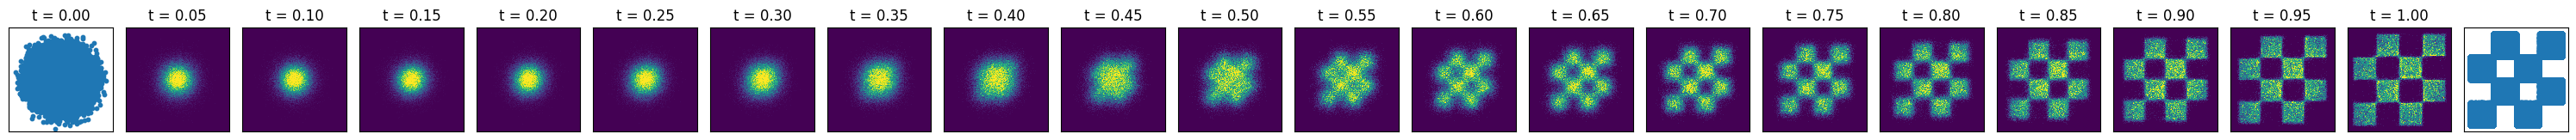

In [10]:
VISUALIZATION_BATCH_SIZE = 300000
x = torch.randn(VISUALIZATION_BATCH_SIZE, 2).to(device)
n_steps = 20
fig, axes = plt.subplots(1, n_steps + 2, figsize=(30, 4), sharex=True, sharey=True)
time_steps = torch.linspace(0, 1.0, n_steps + 1).to(device)

x_1 = inf_train_gen(VISUALIZATION_BATCH_SIZE).to(device)
axes[-1].scatter(x_1.detach().cpu()[:, 0], x_1.detach().cpu()[:, 1], s=10)

axes[0].scatter(x.detach().cpu()[:, 0], x.detach().cpu()[:, 1], s=10)
axes[0].set_title(f't = {time_steps[0]:.2f}')
axes[0].set_xlim(-5.0, 5.0)
axes[0].set_ylim(-5.0, 5.0)
axes[0].set_aspect('equal')

with torch.no_grad():
    for i in range(n_steps):    
        t_start = format_batch_variable(time_steps[i], x)
        t_next = format_batch_variable(time_steps[i + 1],x)
        x = model.euler_step(x_t=x, t_start=t_start, t_next=t_next).detach()
        plot_emp_dist(x.cpu(),axes[i + 1])
        axes[i + 1].set_title(f't = {time_steps[i + 1]:.2f}')
    axes[-1].set_aspect('equal')
    
    plt.tight_layout()
    plt.show()

## 2. Define GLASS Flows reparameterization

In [11]:
torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [12]:
class GlassFlow(nn.Module):
    """A module that takes in a flow matching model and converts it into a posterior flow matching model"""
    def __init__(self,
                 fm_model: nn.Module,
                 clip_val: float = 1e-8,
                 t_min: float = 0.001,
                 t_max: float = 0.999,
                 ):
        """
        fm_model: a flow matching model that accepts an x_t and t arguments and returns a velocity
        """
        super().__init__()
        self.fm_model = fm_model
        self.clip_val = clip_val
        self.t_min = t_min
        self.t_max = t_max
        
    def denoiser(self, x_t, t, **kwargs):
        t = format_batch_variable(t, x_t)
        return x_t + mult_first_dim(self.fm_model(x_t=x_t,t=t, **kwargs), 1-t)

    def alpha_t(self, t):
        return t

    def dot_alpha_t(self, t):
        return torch.ones_like(t)
        
    def sigma_t(self, t):
        return 1-t

    def dot_sigma_t(self, t):
        return -torch.ones_like(t)

    def g_t(self, t):
        return (self.sigma_t_start(t)/torch.clip(self.alpha_t_start(t),min=self.clip_val))**2
    
    def g_t_inv(self, inp_):
        return 1/(1+torch.sqrt(inp_))

    def bar_alpha_s(self, s: Tensor, bar_alpha_final: float):
        return bar_alpha_final*s

    def dot_bar_alpha_s(self, s: Tensor, bar_alpha_final: float):
         return bar_alpha_final*torch.ones_like(s)
        
    def bar_sigma_s(self, s: Tensor, sigma_cond_final: float):
        return s * sigma_cond_final + (1-s)

    def dot_bar_sigma_s(self, s: Tensor, sigma_cond_final: float):
        return torch.ones_like(s) * (sigma_cond_final - 1.0)
    
    def get_num_stable_inverse(self, matrix: Tensor):
        return torch.linalg.inv(matrix + 0.0001 * self.clip_val * torch.eye(matrix.shape[0], device=matrix.device, dtype=matrix.dtype))

    
    def get_generalized_denoiser(self, mu_s: Tensor, Cov_s: Tensor, X_t: Tensor, bar_X_s: Tensor, dtype: torch.dtype, precdtype: torch.dtype, **kwargs):
        inv_Cov_s = self.get_num_stable_inverse(Cov_s)
        bproduct = mu_s @ inv_Cov_s @ mu_s
        t_star = self.g_t_inv(1/torch.clip(bproduct,min=self.clip_val))

        # Compute sufficient statistic:
        weights = self.alpha_t(t_star) * (mu_s @ inv_Cov_s)/torch.clip(bproduct,min=self.clip_val)
        scaled_suff_stat = weights[0] * X_t + weights[1] * bar_X_s

        # Get denoiser
        denoiser = self.denoiser(x_t=scaled_suff_stat.to(dtype), 
                                 t=t_star.to(dtype), 
                                 **kwargs).to(dtype=precdtype)
        return denoiser

    def sample_transition(self,
                          X_t: Tensor, 
                          n_steps: int,
                          t_start: Tensor,
                          t_end: Tensor,
                          corr_rho: Tensor,
                          dtype: torch.dtype,
                          device: torch.device,
                          schedule: str = "s_linear",
                          return_traj: bool = False,
                          precdtype: torch.dtype = torch.float64,
                          **kwargs):

        # Get mean and variance scales:
        alpha_t_start = self.alpha_t(t_start).to(precdtype)
        alpha_t_end = self.alpha_t(t_end).to(precdtype)
        sigma_t_start = self.sigma_t(t_start).to(precdtype)
        sigma_t_end = self.sigma_t(t_end).to(precdtype)

        # Conditional distribution:
        bar_gamma = corr_rho * sigma_t_end/torch.clip(sigma_t_start, min=self.clip_val)
        bar_alpha_final = alpha_t_end - bar_gamma * alpha_t_start
        bar_sigma_final = torch.sqrt(torch.clip((sigma_t_end**2) * (1-corr_rho**2),min=0.0))

        # Time steps:
        s = torch.linspace(self.t_min, self.t_max, n_steps+1, dtype=precdtype, device=device)
        
        # Get schedulers for inner probability path:
        bar_alpha_s = self.bar_alpha_s(s, bar_alpha_final)
        dot_bar_alpha_s = self.dot_bar_alpha_s(s, bar_alpha_final)
        bar_sigma_s = self.bar_sigma_s(s, bar_sigma_final)
        dot_bar_sigma_s = self.dot_bar_sigma_s(s, bar_sigma_final)

        # Get weights:
        w_1 = dot_bar_sigma_s/torch.clip(bar_sigma_s,min=self.clip_val)
        w_2 = dot_bar_alpha_s - w_1 * bar_alpha_s
        w_3 = - w_1 * bar_gamma

        # Convert to higher precision:
        X_t = X_t.to(dtype=precdtype)

        # Initialize:
        bar_X_s = bar_gamma * X_t + torch.randn_like(X_t)

        if return_traj:
            traj_list = [X_s.cpu().detach().float()]

        for i in range(n_steps):


            # Compute t_star:
            mu_s = torch.tensor([alpha_t_start, bar_alpha_s[i]+bar_gamma*alpha_t_start], dtype=precdtype, device=device)
            Cov_s = torch.tensor([[sigma_t_start**2, bar_gamma*(sigma_t_start**2)],
                                   [bar_gamma*(sigma_t_start**2), bar_sigma_s[i]**2 + (bar_gamma**2)*(sigma_t_start**2)]], 
                                    dtype=precdtype, device=device)
            
            denoiser = self.get_generalized_denoiser(
                                                    X_t=X_t, 
                                                    bar_X_s=bar_X_s,
                                                    mu_s=mu_s, 
                                                    Cov_s=Cov_s, 
                                                    dtype=dtype, 
                                                    precdtype=precdtype, 
                                                    **kwargs)

            # Get velocity:
            velocity = w_1[i] * bar_X_s + w_2[i] * denoiser + w_3[i] * X_t

            # Take Euler step:
            s_curr = s[i]
            s_next = s[i+1]
            bar_X_s = bar_X_s + (s_next - s_curr) * velocity

            if return_traj:
                traj_list.append(X_s.cpu().detach())
        
        if return_traj:
            return traj_list
        else:
            return bar_X_s

In [13]:
glass_flow = GlassFlow(fm_model=model)

/tmp/ipykernel_321640/899490743.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t = torch.tensor(t, device=x_t.device, dtype=x_t.dtype)


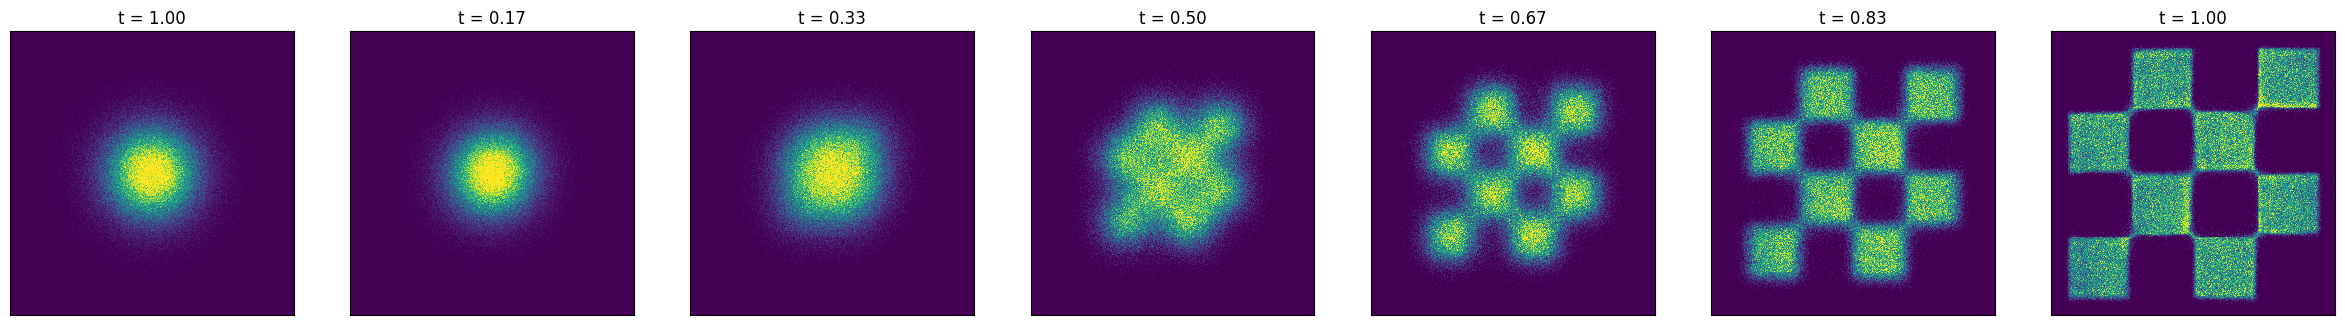

In [28]:
n_transitions = 6
t_backbone = torch.linspace(0,1,n_transitions+1)
batch_size = 300000
X = torch.randn(size=(batch_size,2), device=device)
fig, axes = plt.subplots(1, n_transitions+1, figsize=(30, 4), sharex=True, sharey=True)
plot_emp_dist(X.cpu(),axes[0])
axes[0].set_title(f't = {t_end:.2f}')
for idx in range(n_transitions):
    t_start = t_backbone[idx]
    t_end = t_backbone[idx+1]
    X = glass_flow.sample_transition(
          X, 
          n_steps=10,
          t_start=t_start,
          t_end=t_end,
          corr_rho=0.4,
          dtype=torch.float32,
          device=device)
    plot_emp_dist(X.cpu(),axes[idx+1])
    axes[idx+1].set_title(f't = {t_end:.2f}')
plt.show()